# Random Forest Traffic-Sign Image Classification — Two Feature Extraction Methods

This notebook is built for a **GTSRB-style traffic sign dataset** with the
following layout:

```
notebook.ipynb
dataset/
├── Train/
│   ├── 0 - Speed Limit 20/
│   │   └── *.png / *.jpg
│   ├── 2 - Speed Limit 50/
│   │   └── ...
│   └── ...
├── Test/                     # mixed classes, NOT split into sub-folders
│   └── *.png / *.jpg
├── Train.csv                 # Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
├── Test_cleaned.csv          # same columns as Train.csv
└── Meta.csv                  # Path,ClassId,ShapeId,ColorId,SignId
```

Key adaptations for this dataset:

- **Labels & file lists come from `Train.csv` / `Test_cleaned.csv`**, not from
  folder scanning — this is required for `Test/`, which contains mixed
  classes with no sub-folders.
- Each row's **ROI (`Roi.X1/Y1/X2/Y2`)** is used to **crop the sign region**
  out of the raw photo before resizing/feature extraction (raw traffic-sign
  photos include background around the sign).
- Human-readable **class names are parsed from the `Train/<id> - <name>/`
  folder names** (e.g. `"0 - Speed Limit 20"` → class id `0`, name
  `"Speed Limit 20"`).
- `Meta.csv` (one representative icon per class + `ShapeId` / `ColorId` /
  `SignId`) is used for a quick visual class-reference grid.
- Extracted features are **cached to disk** (`joblib`) so re-running the
  notebook doesn't require re-extracting features for the whole dataset
  every time.
- An optional **per-class subsample cap** is provided since traffic-sign
  datasets like this can contain tens of thousands of images — useful while
  iterating before a full run.

As before, two feature extraction methods are used, then combined:

1. **HOG** (Histogram of Oriented Gradients) — shape / edge based
2. **Color Histogram** (HSV) — color distribution based
3. **Combined** — HOG + Color Histogram concatenated

For **each** feature set the notebook: holds out validation images from
training, runs **Stratified K-Fold + grid search** over Random Forest
hyperparameters, trains & **saves** a final model (separate file per feature
set), evaluates on `Test/` (accuracy, F1, precision, recall, confusion
matrix, inference speed), and displays up to **100 random success cases**
plus **all failure cases**.


In [ ]:
# (Uncomment if running in a fresh environment)
# !pip install opencv-python scikit-image scikit-learn matplotlib seaborn pandas joblib


In [12]:
import os
import re
import time
import random

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from skimage.feature import hog

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

from IPython.display import display

%matplotlib inline
sns.set_style("whitegrid")


## 1. Configuration

In [13]:
# --- Dataset locations ----------------------------------------------------
DATASET_DIR = "dataset"
TRAIN_DIR = os.path.join(DATASET_DIR, "Train")     # class sub-folders: "<id> - <name>"
TEST_DIR = os.path.join(DATASET_DIR, "Test")       # mixed images, no sub-folders
TRAIN_CSV = os.path.join(DATASET_DIR, "Train.csv")
TEST_CSV = os.path.join(DATASET_DIR, "Test_cleaned.csv")
META_CSV = os.path.join(DATASET_DIR, "Meta.csv")

MODEL_DIR = "/classification result 3/saved_models"             # trained models (.pkl) are stored here
FEATURE_CACHE_DIR = os.path.join(MODEL_DIR, "feature_cache")
FORCE_RECOMPUTE_FEATURES = False       # set True to ignore any cached features

# --- Feature extraction settings ------------------------------------------
IMG_SIZE = (64, 64)        # images are cropped to their ROI, then resized to this size
COLOR_BINS = (8, 8, 8)     # H, S, V histogram bins for the color-histogram feature

# --- Optional speed-up while iterating -------------------------------------
# Traffic-sign datasets can have tens of thousands of images; cap the number
# of TRAINING images per class (None = use everything) and/or the total
# number of TEST images (None = use everything) while experimenting.
SUBSAMPLE_TRAIN_PER_CLASS = None    # e.g. 300
SUBSAMPLE_TEST_TOTAL = None         # e.g. 3000

# --- Reproducibility ---------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FEATURE_CACHE_DIR, exist_ok=True)


## 2. Class Names & Metadata

Class descriptions are parsed straight out of the `Train/<id> - <name>/`
folder names (e.g. `"0 - Speed Limit 20"`), so plots and reports can show
`"Speed Limit 20"` instead of a bare integer.


In [14]:
def parse_class_names(train_dir):
    """Builds {class_id: readable_name} from 'Train/<id> - <name>' folders."""
    mapping = {}
    for entry in sorted(os.listdir(train_dir)):
        full_path = os.path.join(train_dir, entry)
        if not os.path.isdir(full_path):
            continue
        m = re.match(r'^\s*(\d+)\s*-\s*(.+?)\s*$', entry)
        if m:
            mapping[int(m.group(1))] = m.group(2)
        else:
            print(f"  [warn] Could not parse a class id/name from folder: '{entry}'")
    return mapping


class_id_to_name = parse_class_names(TRAIN_DIR)
print(f"Parsed {len(class_id_to_name)} class names, e.g.:")
for cid in sorted(class_id_to_name)[:5]:
    print(f"  {cid}: {class_id_to_name[cid]}")


Parsed 32 class names, e.g.:
  0: Speed Limit 20
  2: Speed Limit 50
  3: Speed Limit 60
  4: Speed Limit 70
  5: Speed Limit 80


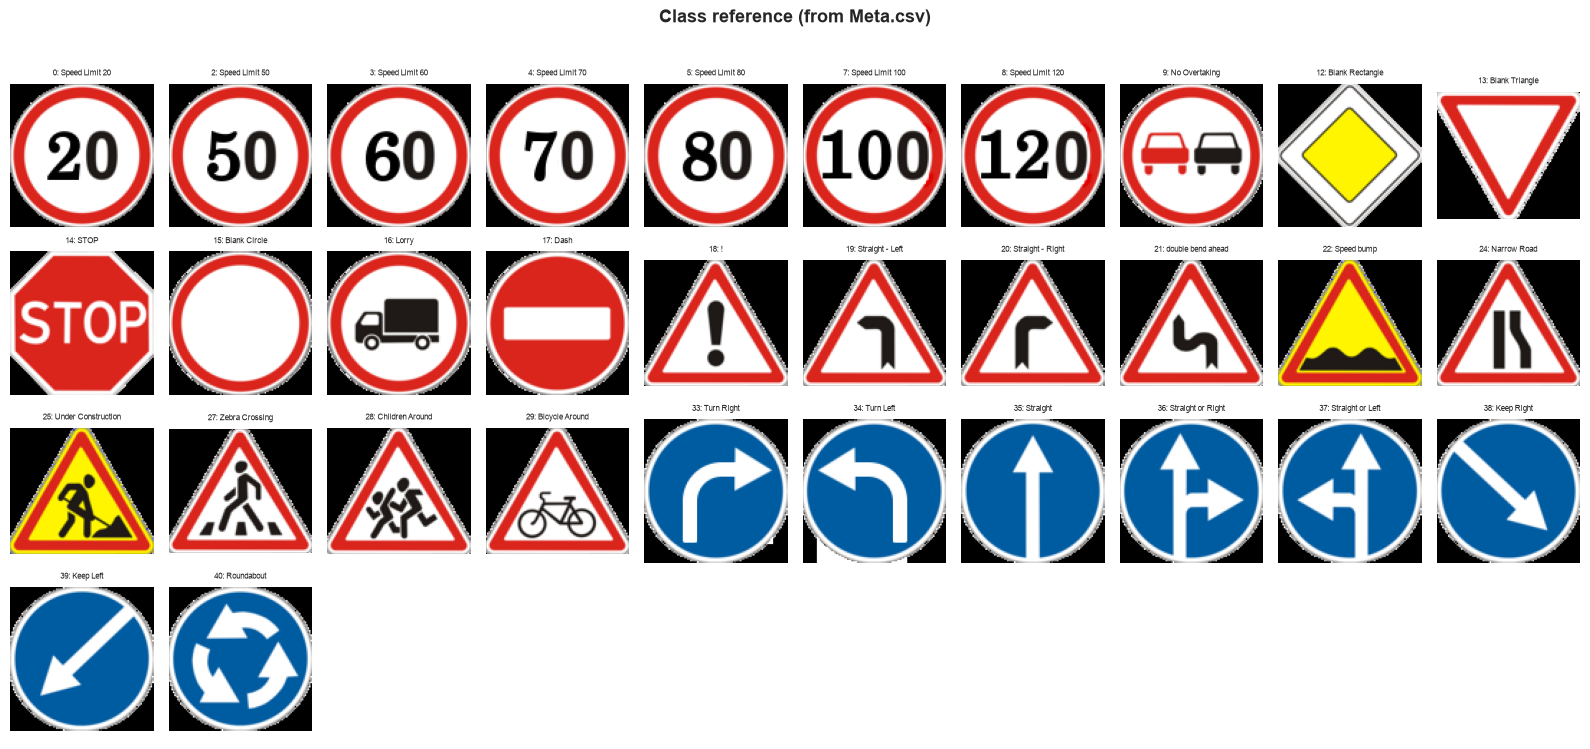

In [15]:
# Optional: visual class reference sheet built from Meta.csv (one icon per class)
try:
    meta_df = pd.read_csv(META_CSV)
    meta_df = meta_df.sort_values('ClassId')
    n_show = min(len(meta_df), 43)
    n_cols = 10
    n_rows = int(np.ceil(n_show / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.6, n_rows * 1.9))
    axes = np.atleast_1d(axes).reshape(-1)
    for ax, (_, row) in zip(axes, meta_df.head(n_show).iterrows()):
        icon_path = os.path.join(DATASET_DIR, row['Path'])
        if os.path.isfile(icon_path):
            img = cv2.cvtColor(cv2.imread(icon_path), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
        cid = int(row['ClassId'])
        ax.set_title(f"{cid}: {class_id_to_name.get(cid, '?')}", fontsize=6)
        ax.axis('off')
    for ax in axes[n_show:]:
        ax.axis('off')
    fig.suptitle("Class reference (from Meta.csv)", fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
except FileNotFoundError:
    print(f"Meta.csv not found at {META_CSV} — skipping class reference sheet.")


## 3. Loading Image Lists & Labels from the CSV Files

`Train.csv` / `Test_cleaned.csv` are the source of truth for file paths,
`ClassId`, and the sign **ROI** (`Roi.X1/Y1/X2/Y2`). Since `Path` values in
these CSVs aren't guaranteed to resolve directly under `DATASET_DIR` (folder
names include the descriptive suffix), a small fallback index built by
walking `Train/` and `Test/` is used to resolve files by basename if the
direct join fails.


In [16]:
def build_filename_index(root_dir):
    """Maps {filename: full_path} for every file under root_dir (fallback lookup)."""
    index = {}
    for dirpath, _, filenames in os.walk(root_dir):
        for fn in filenames:
            index[fn] = os.path.join(dirpath, fn)
    return index


def resolve_image_path(csv_path, dataset_dir, filename_index):
    direct = os.path.normpath(os.path.join(dataset_dir, csv_path))
    if os.path.isfile(direct):
        return direct
    return filename_index.get(os.path.basename(csv_path))


train_filename_index = build_filename_index(TRAIN_DIR)
test_filename_index = build_filename_index(TEST_DIR)


def build_records(csv_path, dataset_dir, filename_index):
    df = pd.read_csv(csv_path)
    paths, labels, rois = [], [], []
    missing = 0
    for _, row in df.iterrows():
        resolved = resolve_image_path(row['Path'], dataset_dir, filename_index)
        if resolved is None:
            missing += 1
            continue
        paths.append(resolved)
        labels.append(int(row['ClassId']))
        rois.append((
            int(row['Roi.X1']), int(row['Roi.Y1']),
            int(row['Roi.X2']), int(row['Roi.Y2']),
        ))
    if missing:
        print(f"  [warn] {missing}/{len(df)} rows in {os.path.basename(csv_path)} "
              f"could not be resolved to an existing file and were skipped.")
    return paths, labels, rois


train_paths, train_labels, train_rois = build_records(TRAIN_CSV, DATASET_DIR, train_filename_index)
test_paths, test_labels, test_rois = build_records(TEST_CSV, DATASET_DIR, test_filename_index)

print(f"Training rows resolved: {len(train_paths)}  |  classes: {len(set(train_labels))}")
print(f"Testing rows resolved : {len(test_paths)}")


  [warn] 2220/32399 rows in Train.csv could not be resolved to an existing file and were skipped.
Training rows resolved: 30179  |  classes: 32
Testing rows resolved : 9720


In [17]:
def subsample_per_class(paths, labels, rois, cap, seed=RANDOM_STATE):
    if cap is None:
        return paths, labels, rois
    rng = np.random.RandomState(seed)
    by_class = {}
    for p, l, r in zip(paths, labels, rois):
        by_class.setdefault(l, []).append((p, r))
    new_paths, new_labels, new_rois = [], [], []
    for l, items in by_class.items():
        chosen = rng.permutation(len(items))[:cap]
        for i in chosen:
            p, r = items[i]
            new_paths.append(p); new_labels.append(l); new_rois.append(r)
    return new_paths, new_labels, new_rois


def subsample_total(paths, labels, rois, cap, seed=RANDOM_STATE):
    if cap is None or cap >= len(paths):
        return paths, labels, rois
    rng = np.random.RandomState(seed)
    chosen = rng.choice(len(paths), size=cap, replace=False)
    return [paths[i] for i in chosen], [labels[i] for i in chosen], [rois[i] for i in chosen]


train_paths, train_labels, train_rois = subsample_per_class(
    train_paths, train_labels, train_rois, SUBSAMPLE_TRAIN_PER_CLASS
)
test_paths, test_labels, test_rois = subsample_total(
    test_paths, test_labels, test_rois, SUBSAMPLE_TEST_TOTAL
)

print(f"Using {len(train_paths)} training images and {len(test_paths)} testing images "
      f"after any subsampling.")


Using 30179 training images and 9720 testing images after any subsampling.


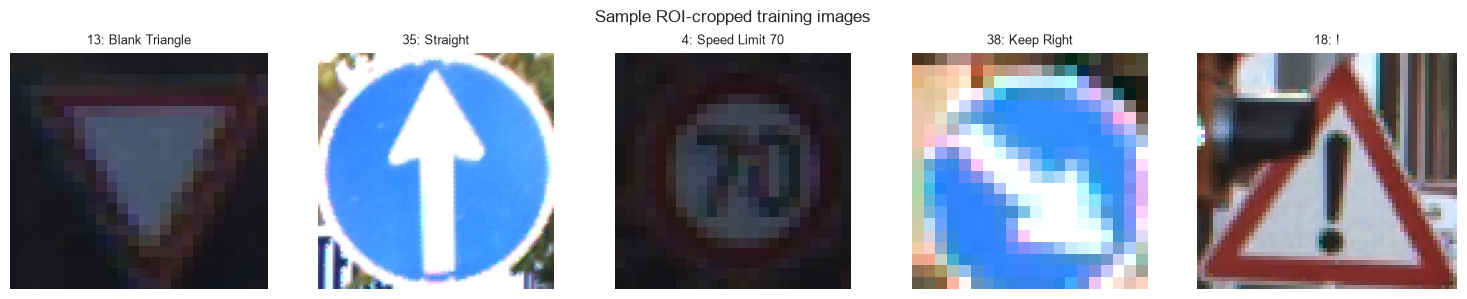

In [18]:
# Quick sanity peek: a handful of random (ROI-cropped) training images with their labels
def crop_roi(img, roi):
    x1, y1, x2, y2 = roi
    h, w = img.shape[:2]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)
    if x2 <= x1 or y2 <= y1:
        return img
    return img[y1:y2, x1:x2]


sample_idx = np.random.choice(len(train_paths), size=min(5, len(train_paths)), replace=False)
fig, axes = plt.subplots(1, len(sample_idx), figsize=(3 * len(sample_idx), 3))
axes = np.atleast_1d(axes)
for ax, i in zip(axes, sample_idx):
    img = cv2.cvtColor(crop_roi(cv2.imread(train_paths[i]), train_rois[i]), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    cid = train_labels[i]
    ax.set_title(f"{cid}: {class_id_to_name.get(cid, '?')}", fontsize=9)
    ax.axis('off')
plt.suptitle("Sample ROI-cropped training images")
plt.tight_layout()
plt.show()


## 4. Feature Extraction (with ROI cropping + on-disk caching)

Two different, complementary feature extraction methods are used:

- **HOG** — local shape/edge/gradient structure (grayscale)
- **Color Histogram (HSV)** — color distribution, independent of shape

Every image is first cropped to its ROI (the actual sign region), resized,
then both feature vectors are computed in a single pass so the two feature
sets — and their later concatenation — always refer to exactly the same set
of successfully-read images. Results are cached to disk with `joblib` so
re-running this cell doesn't require recomputing features for the whole
dataset again.


In [19]:
def extract_hog(gray_resized_img):
    return hog(
        gray_resized_img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True,
    )


def extract_color_histogram(color_resized_img, bins=COLOR_BINS):
    hsv = cv2.cvtColor(color_resized_img, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist, hist)
    return hist.flatten()


def build_dual_features(paths, labels, rois, img_size=IMG_SIZE,
                         cache_path=None, force_recompute=False):
    if cache_path and os.path.isfile(cache_path) and not force_recompute:
        print(f"  Loading cached features from {cache_path}")
        return joblib.load(cache_path)

    hog_feats, color_feats, valid_labels, valid_paths = [], [], [], []
    for path, label, roi in zip(paths, labels, rois):
        img = cv2.imread(path)
        if img is None:
            print(f"  [skip] could not read: {path}")
            continue
        cropped = crop_roi(img, roi)
        img_r = cv2.resize(cropped, img_size)
        gray = cv2.cvtColor(img_r, cv2.COLOR_BGR2GRAY)

        hog_feats.append(extract_hog(gray))
        color_feats.append(extract_color_histogram(img_r))
        valid_labels.append(label)
        valid_paths.append(path)

    result = (np.array(hog_feats), np.array(color_feats), np.array(valid_labels), valid_paths)
    if cache_path:
        joblib.dump(result, cache_path)
        print(f"  Cached features to {cache_path}")
    return result


print("Extracting/loading features for TRAINING images...")
X_train_hog, X_train_color, y_train, train_paths_valid = build_dual_features(
    train_paths, train_labels, train_rois,
    cache_path=os.path.join(FEATURE_CACHE_DIR, "train_features.joblib"),
    force_recompute=FORCE_RECOMPUTE_FEATURES,
)

print("Extracting/loading features for TESTING images...")
X_test_hog, X_test_color, y_test, test_paths_valid = build_dual_features(
    test_paths, test_labels, test_rois,
    cache_path=os.path.join(FEATURE_CACHE_DIR, "test_features.joblib"),
    force_recompute=FORCE_RECOMPUTE_FEATURES,
)

print(f"HOG feature length  : {X_train_hog.shape[1]}")
print(f"Color feature length: {X_train_color.shape[1]}")


Extracting/loading features for TRAINING images...
  Loading cached features from /classification result 3/saved_models\feature_cache\train_features.joblib
Extracting/loading features for TESTING images...
  Loading cached features from /classification result 3/saved_models\feature_cache\test_features.joblib
HOG feature length  : 1764
Color feature length: 512


In [20]:
# --- Combined feature set: concatenate HOG + Color Histogram ---------------
X_train_combined = np.hstack([X_train_hog, X_train_color])
X_test_combined = np.hstack([X_test_hog, X_test_color])

print(f"Combined feature length: {X_train_combined.shape[1]}")

# All classes present across train + test, used for consistent report/plot ordering
ALL_LABELS = sorted(set(np.unique(y_train)) | set(np.unique(y_test)))


Combined feature length: 2276


## 5. Reusable Training + Evaluation Pipeline

Applied to **each** feature set (HOG, Color Histogram, Combined):

1. Split off part of the training images for **validation**
2. **Stratified K-Fold** cross-validation + **grid search** over Random
   Forest hyperparameters
3. Show training/CV results (best params, score table, plot)
4. Train the **final** model on the full training set and **save** it under
   a feature-specific filename
5. Test — accuracy, F1, precision, recall, confusion matrix, inference speed
6. Display up to **100 random successful** predictions
7. Display **all failed** predictions


In [21]:
def display_image_grid(indices, image_paths, y_true, y_pred, class_id_to_name,
                        title, color='green', max_cols=10, cell_size=2.1):
    """Displays a grid of images with True(T)/Predicted(P) class names."""
    n = len(indices)
    if n == 0:
        print(f"[{title}] Nothing to display.")
        return

    n_cols = min(max_cols, n)
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * cell_size, n_rows * (cell_size + 0.5)))
    axes = np.atleast_1d(axes).reshape(-1)

    for ax_i, idx in enumerate(indices):
        img = cv2.cvtColor(cv2.imread(image_paths[idx]), cv2.COLOR_BGR2RGB)
        axes[ax_i].imshow(img)
        true_id, pred_id = int(y_true[idx]), int(y_pred[idx])
        true_name = class_id_to_name.get(true_id, f"Class {true_id}")
        pred_name = class_id_to_name.get(pred_id, f"Class {pred_id}")
        axes[ax_i].set_title(f"T:{true_name}\nP:{pred_name}", fontsize=7, color=color)
        axes[ax_i].axis('off')

    for ax_i in range(n, len(axes)):
        axes[ax_i].axis('off')

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# Hyperparameter grid searched for every feature set.
PARAM_GRID = {
    'n_estimators': [100, 200],
    'max_depth': [None, 15, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

N_SPLITS = 5                # K for K-Fold cross-validation
VAL_HOLDOUT_FRACTION = 0.2  # fraction of training images reserved for validation


def run_pipeline(feature_name, X_train_full, y_train_full, X_test, y_test,
                  train_image_paths, test_image_paths, class_id_to_name, all_labels,
                  param_grid=PARAM_GRID, n_splits=N_SPLITS, random_state=RANDOM_STATE):

    print("=" * 90)
    print(f"  PIPELINE — FEATURE SET: {feature_name.upper()}")
    print("=" * 90)

    target_names = [class_id_to_name.get(c, f"Class {c}") for c in all_labels]

    # ---- 1. Train / validation split (some training images held out) ----
    X_tr, X_val, y_tr, y_val, _, path_val = train_test_split(
        X_train_full, y_train_full, train_image_paths,
        test_size=VAL_HOLDOUT_FRACTION, stratify=y_train_full, random_state=random_state
    )
    print(f"Training subset: {len(X_tr)} images | Validation subset: {len(X_val)} images")

    # ---- 2. K-Fold CV + hyperparameter grid search -----------------------
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    grid_search = GridSearchCV(
        estimator=RandomForestClassifier(random_state=random_state),
        param_grid=param_grid,
        cv=cv,
        scoring='f1_weighted',
        n_jobs=-1,
        return_train_score=True,
    )
    grid_search.fit(X_tr, y_tr)

    print(f"\nBest hyperparameters: {grid_search.best_params_}")
    print(f"Best CV F1 (weighted): {grid_search.best_score_:.4f}")

    cv_results = pd.DataFrame(grid_search.cv_results_)
    cv_results_sorted = cv_results.sort_values('mean_test_score', ascending=False)
    print("\nTop 10 hyperparameter combinations:")
    display(cv_results_sorted[['params', 'mean_test_score', 'std_test_score', 'mean_train_score']].head(10))

    top10 = cv_results_sorted.head(10).iloc[::-1]
    plt.figure(figsize=(10, 5))
    plt.barh(range(len(top10)), top10['mean_test_score'], xerr=top10['std_test_score'], color='steelblue')
    plt.yticks(range(len(top10)), [str(p) for p in top10['params']], fontsize=7)
    plt.xlabel('Mean CV F1-weighted score')
    plt.title(f'Top 10 Hyperparameter Combinations — {feature_name}')
    plt.tight_layout()
    plt.show()

    # ---- 3. Evaluate best model on the held-out validation subset -------
    best_model = grid_search.best_estimator_
    val_preds = best_model.predict(X_val)
    val_acc = accuracy_score(y_val, val_preds)
    val_f1 = f1_score(y_val, val_preds, average='weighted')
    print(f"\nValidation — Accuracy: {val_acc:.4f} | F1 (weighted): {val_f1:.4f}")
    print(classification_report(y_val, val_preds, labels=all_labels,
                                 target_names=target_names, zero_division=0))

    cm_val = confusion_matrix(y_val, val_preds, labels=all_labels)
    plt.figure(figsize=(min(0.35 * len(all_labels) + 3, 16), min(0.35 * len(all_labels) + 3, 14)))
    sns.heatmap(cm_val, cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Validation Confusion Matrix — {feature_name}')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.xticks(fontsize=6, rotation=90); plt.yticks(fontsize=6)
    plt.tight_layout()
    plt.show()

    # ---- 4. Retrain final model on the FULL training set -----------------
    final_model = RandomForestClassifier(**grid_search.best_params_, random_state=random_state)
    final_model.fit(X_train_full, y_train_full)

    model_path = os.path.join(MODEL_DIR, f"rf_model_{feature_name}.pkl")
    joblib.dump(final_model, model_path)
    print(f"\nSaved final '{feature_name}' model to: {model_path}")

    # ---- 5. Test set evaluation -------------------------------------------
    start = time.time()
    test_preds = final_model.predict(X_test)
    elapsed = time.time() - start
    avg_ms = (elapsed / len(X_test)) * 1000
    throughput = len(X_test) / elapsed

    test_acc = accuracy_score(y_test, test_preds)
    test_f1 = f1_score(y_test, test_preds, average='weighted')
    test_precision = precision_score(y_test, test_preds, average='weighted', zero_division=0)
    test_recall = recall_score(y_test, test_preds, average='weighted', zero_division=0)

    print("\n--- TEST RESULTS ---")
    print(f"Accuracy          : {test_acc:.4f}")
    print(f"F1 (weighted)     : {test_f1:.4f}")
    print(f"Precision         : {test_precision:.4f}")
    print(f"Recall            : {test_recall:.4f}")
    print(f"Total inference   : {elapsed:.4f}s for {len(X_test)} images")
    print(f"Avg inference time: {avg_ms:.4f} ms/image  |  Throughput: {throughput:.2f} images/sec")
    print("\nClassification report:\n",
          classification_report(y_test, test_preds, labels=all_labels,
                                 target_names=target_names, zero_division=0))

    cm_test = confusion_matrix(y_test, test_preds, labels=all_labels)
    plt.figure(figsize=(min(0.35 * len(all_labels) + 3, 16), min(0.35 * len(all_labels) + 3, 14)))
    sns.heatmap(cm_test, cmap='Greens', xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Test Confusion Matrix — {feature_name}')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.xticks(fontsize=6, rotation=90); plt.yticks(fontsize=6)
    plt.tight_layout()
    plt.show()

    # ---- 6. Display up to 100 random SUCCESS cases ------------------------
    correct_idx = np.where(test_preds == y_test)[0]
    n_show = min(100, len(correct_idx))
    chosen = np.random.choice(correct_idx, size=n_show, replace=False) if n_show > 0 else np.array([], dtype=int)
    display_image_grid(
        chosen, test_image_paths, y_test, test_preds, class_id_to_name,
        title=f"Random Success Cases — {feature_name} ({n_show} of {len(correct_idx)} shown)",
        color='green'
    )

    # ---- 7. Display ALL FAILURE cases --------------------------------------
    wrong_idx = np.where(test_preds != y_test)[0]
    print(f"\nTotal failed cases: {len(wrong_idx)} / {len(y_test)}")
    display_image_grid(
        wrong_idx, test_image_paths, y_test, test_preds, class_id_to_name,
        title=f"All Failure Cases — {feature_name} ({len(wrong_idx)} shown)",
        color='red'
    )

    return {
        'feature': feature_name,
        'model_path': model_path,
        'best_params': grid_search.best_params_,
        'cv_best_f1': grid_search.best_score_,
        'val_accuracy': val_acc,
        'val_f1': val_f1,
        'test_accuracy': test_acc,
        'test_f1': test_f1,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'total_inference_time_s': elapsed,
        'avg_inference_time_ms': avg_ms,
        'throughput_img_per_sec': throughput,
    }


## 6. Run the Pipeline for Feature Set 1 — HOG

In [22]:
result_hog = run_pipeline(
    feature_name="hog",
    X_train_full=X_train_hog, y_train_full=y_train,
    X_test=X_test_hog, y_test=y_test,
    train_image_paths=train_paths_valid, test_image_paths=test_paths_valid,
    class_id_to_name=class_id_to_name, all_labels=ALL_LABELS,
)


  PIPELINE — FEATURE SET: HOG
Training subset: 23831 images | Validation subset: 5958 images


OSError: [WinError 1450] Insufficient system resources exist to complete the requested service

## 7. Run the Pipeline for Feature Set 2 — Color Histogram

In [ ]:
result_color = run_pipeline(
    feature_name="color_histogram",
    X_train_full=X_train_color, y_train_full=y_train,
    X_test=X_test_color, y_test=y_test,
    train_image_paths=train_paths_valid, test_image_paths=test_paths_valid,
    class_id_to_name=class_id_to_name, all_labels=ALL_LABELS,
)


## 8. Run the Pipeline for the Combined Feature Set (HOG + Color Histogram)

In [ ]:
result_combined = run_pipeline(
    feature_name="combined_hog_color",
    X_train_full=X_train_combined, y_train_full=y_train,
    X_test=X_test_combined, y_test=y_test,
    train_image_paths=train_paths_valid, test_image_paths=test_paths_valid,
    class_id_to_name=class_id_to_name, all_labels=ALL_LABELS,
)


## 9. Compare All Three Models

Each model was trained and saved separately (see `saved_models/`):

- `rf_model_hog.pkl`
- `rf_model_color_histogram.pkl`
- `rf_model_combined_hog_color.pkl`


In [ ]:
summary_df = pd.DataFrame([result_hog, result_color, result_combined])[
    ['feature', 'best_params', 'cv_best_f1', 'val_accuracy', 'val_f1',
     'test_accuracy', 'test_f1', 'test_precision', 'test_recall',
     'avg_inference_time_ms', 'throughput_img_per_sec', 'model_path']
]
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
plot_specs = [
    ('test_accuracy', 'Test Accuracy'),
    ('test_f1', 'Test F1 (weighted)'),
    ('throughput_img_per_sec', 'Throughput (images/sec)'),
]
colors = ['#4C72B0', '#DD8452', '#55A868']
for ax, (metric, title) in zip(axes, plot_specs):
    ax.bar(summary_df['feature'], summary_df[metric], color=colors)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print("\nAll trained models are stored separately under:", os.path.abspath(MODEL_DIR))
